### IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage.io
import os
import tqdm
import glob
import tensorflow

from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

from skimage.io import imread, imshow
from skimage.transform import resize
from skimage.color import gray2rgb

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.densenet import DenseNet169
from tensorflow.keras.preprocessing.image import load_img, img_to_array

### IMPORT / VIEWING / PREPROCESSING DATASET

> `DATA AUGMENTATION`

In [2]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   rotation_range=30,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   vertical_flip=True,
                                   validation_split = 0.2)

valid_datagen = ImageDataGenerator(rescale = 1./255,
                                   validation_split = 0.2)

test_datagen  = ImageDataGenerator(rescale = 1./255)

In [3]:
# Upload the ZIP file
from google.colab import files
uploaded = files.upload()

# Unzip the file
import zipfile
import os

# Assuming the uploaded file is named 'example.zip'
file_name = list(uploaded.keys())[0]
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall('/content')

# List the files in the unzipped folder to verify
os.listdir('/content')


Saving ALZ.zip to ALZ.zip


['.config', 'Alzheimer_s Dataset', 'ALZ.zip', 'sample_data']

In [4]:
train_dataset  = train_datagen.flow_from_directory(directory = '/content/Alzheimer_s Dataset/train',
                                                   target_size = (224,224),
                                                   class_mode = 'categorical',
                                                   subset = 'training',
                                                   batch_size = 128)


Found 4098 images belonging to 4 classes.


In [5]:
valid_dataset = valid_datagen.flow_from_directory(directory = '/content/Alzheimer_s Dataset/train',
                                                  target_size = (224,224),
                                                  class_mode = 'categorical',
                                                  subset = 'validation',
                                                  batch_size = 128)

Found 1023 images belonging to 4 classes.


100%|██████████| 5/5 [00:13<00:00,  2.77s/it]


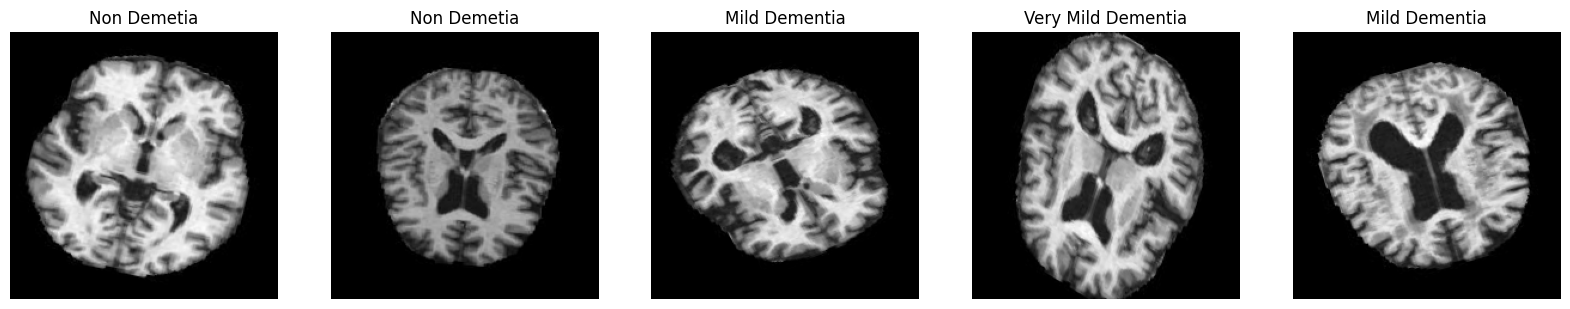

In [7]:
fig, ax = plt.subplots(nrows = 1, ncols = 5, figsize=(20,20))

for i in tqdm(range(0,5)):
    rand1 = np.random.randint(len(train_dataset))
    rand2 = np.random.randint(100)
    ax[i].imshow(train_dataset[rand1][0][rand2])
    ax[i].axis('off')
    a = train_dataset[rand1][1][rand2]
    if a[0] == 1:
        ax[i].set_title('Mild Dementia')
    elif a[1] == 1:
        ax[i].set_title('Moderate Dementia')
    elif a[2] == 1:
        ax[i].set_title('Non Demetia')
    elif a[3] == 1:
        ax[i].set_title('Very Mild Dementia')

Mild Dementia:

This stage involves noticeable symptoms that affect daily life, such as memory loss, confusion, trouble handling money, and difficulty with complex tasks. However, individuals can still maintain a certain level of independence.
Moderate Dementia:

At this stage, symptoms become more pronounced and begin to significantly impact daily activities and personal care. Individuals might have difficulty recognizing family and friends, increased confusion, and may require assistance with basic tasks such as eating, dressing, and bathing.
Non Dementia:

This class refers to individuals who do not exhibit any significant cognitive decline or symptoms of dementia. Their cognitive functions are considered to be within the normal range for their age.
Very Mild Dementia:

This is an early stage where symptoms are very subtle and might be mistaken for normal aging. There may be slight memory lapses and a bit of difficulty in concentrating, but these do not interfere significantly with daily life.

### MODEL BUILDING

In [8]:
# Model Initialization

base_model = DenseNet169(input_shape=(224,224,3),
                         include_top=False,
                         weights="imagenet")

51877672/51877672 [==============================] - 4s 0us/step


In [9]:
# Freezing Layers

for layer in base_model.layers:
    layer.trainable=False

In [10]:
# Building Model

model=Sequential()
model.add(base_model)
model.add(Dropout(0.5))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(2048,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1024,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(4,activation='softmax'))

In [11]:
# Summary

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet169 (Functional)    (None, 7, 7, 1664)        12642880  
                                                                 
 dropout (Dropout)           (None, 7, 7, 1664)        0         
                                                                 
 flatten (Flatten)           (None, 81536)             0         
                                                                 
 batch_normalization (Batch  (None, 81536)             326144    
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 2048)              166987776 
                                                                 
 batch_normalization_1 (Bat  (None, 2048)              8192      
 chNormalization)                                       

In [12]:
from tensorflow.keras.optimizers import Adam

# Model Compile
OPT = Adam(learning_rate=0.001)

model.compile(loss='categorical_crossentropy',
              metrics=[tensorflow.keras.metrics.AUC(name='auc')],
              optimizer=OPT)


In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define the file path for saving the best model weights
filepath = './best_weights.keras'

# Early stopping callback
earlystopping = EarlyStopping(monitor='val_auc',
                              mode='max',
                              patience=15,
                              verbose=1)

# Model checkpoint callback
checkpoint = ModelCheckpoint(filepath,
                             monitor='val_auc',
                             mode='max',
                             save_best_only=True,
                             verbose=1)

# List of callbacks
callback_list = [earlystopping, checkpoint]


In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint('checkpoint.h5', monitor='val_loss', save_best_only=True, mode='min')
callback_list.append(checkpoint)

model_history = model.fit(train_dataset,
                          validation_data=valid_dataset,
                          epochs=100,
                          callbacks=callback_list,
                          verbose=1)
model.load_weights('checkpoint.h5')


Epoch 1/100
33/33 [==============================] - ETA: 0s - loss: 0.8805 - auc: 0.8701
Epoch 1: val_auc improved from 0.76769 to 0.77322, saving model to ./best_weights.keras
33/33 [==============================] - 216s 7s/step - loss: 0.8805 - auc: 0.8701 - val_loss: 1.3797 - val_auc: 0.7732
Epoch 2/100
33/33 [==============================] - ETA: 0s - loss: 0.8589 - auc: 0.8764
Epoch 2: val_auc improved from 0.77322 to 0.77587, saving model to ./best_weights.keras
33/33 [==============================] - 263s 8s/step - loss: 0.8589 - auc: 0.8764 - val_loss: 1.3225 - val_auc: 0.7759
Epoch 3/100
33/33 [==============================] - ETA: 0s - loss: 0.8329 - auc: 0.8818
Epoch 3: val_auc improved from 0.77587 to 0.78047, saving model to ./best_weights.keras
33/33 [==============================] - 270s 8s/step - loss: 0.8329 - auc: 0.8818 - val_loss: 1.2928 - val_auc: 0.7805
Epoch 4/100
33/33 [==============================] - ETA: 0s - loss: 0.7921 - auc: 0.8931
Epoch 4: val_auc

In [16]:
# Sauvegarder le modèle
model.save('ALZmodel.h5')

# Charger le modèle
from tensorflow.keras.models import load_model
model = load_model('ALZmodel.h5')


### MODEL EVALUATION

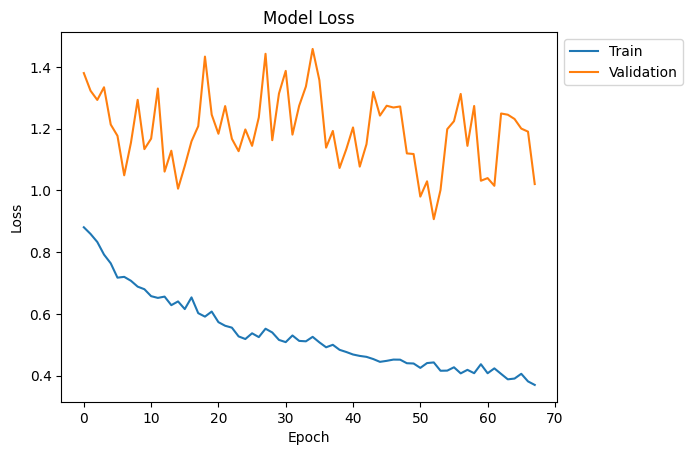

In [17]:
# Summarize history for loss

plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left', bbox_to_anchor=(1,1))
plt.show()

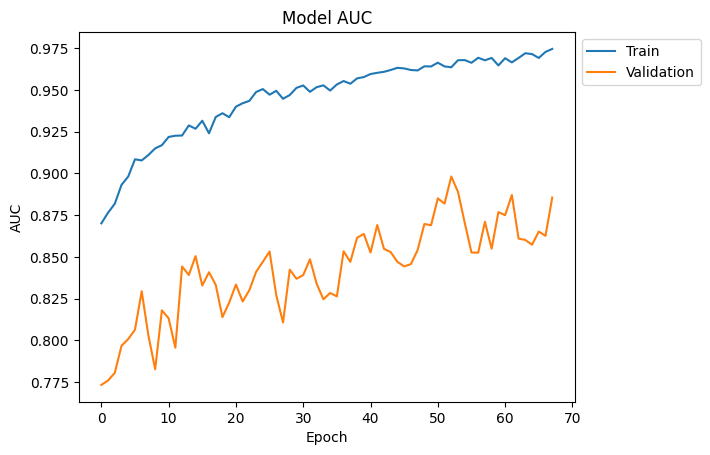

In [18]:
# Summarize history for loss

plt.plot(model_history.history['auc'])
plt.plot(model_history.history['val_auc'])
plt.title('Model AUC')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left', bbox_to_anchor=(1,1))
plt.show()

In [20]:
# Test Data

test_dataset  = test_datagen.flow_from_directory(directory = '/content/Alzheimer_s Dataset/test',
                                                 target_size = (224,224),
                                                 class_mode = 'categorical',
                                                 batch_size = 128)

Found 1268 images belonging to 4 classes.


In [21]:
# Evaluating Loss and AUC

model.evaluate(test_dataset)

10/10 [==============================] - 22s 2s/step - loss: 1.1265 - auc: 0.8877


[1.1265069246292114, 0.8877242803573608]

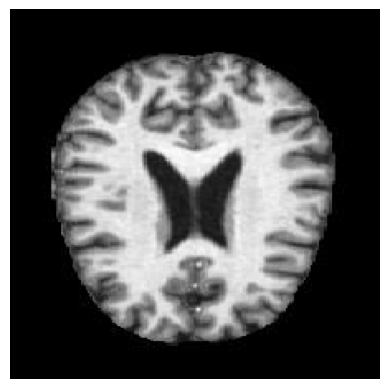

1/1 [==============================] - 40s 40s/step
99.92 % chances are there that the image is NonDemented


In [24]:
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

dic = test_dataset.class_indices
idc = {v: k for k, v in dic.items()}

# Load and preprocess the image
img = load_img('/content/Alzheimer_s Dataset/test/NonDemented/26 (100).jpg', target_size=(224, 224, 3))
img = img_to_array(img)
img = img / 255.0

# Display the image
plt.imshow(img)
plt.axis('off')
plt.show()

# Expand dimensions to match the input shape for the model
img = np.expand_dims(img, axis=0)

# Make a prediction
predictions = model.predict(img)
answer = np.argmax(predictions, axis=1)
probability = round(np.max(predictions) * 100, 2)

print(f"{probability} % chances are there that the image is {idc[answer[0]]}")


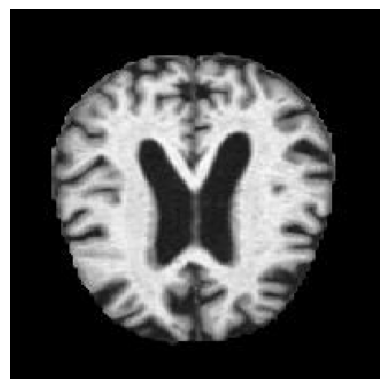

1/1 [==============================] - 0s 33ms/step
88.88 % chances are there that the image is MildDemented


In [33]:
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

# Dictionary for class indices
dic = test_dataset.class_indices
idc = {v: k for k, v in dic.items()}

# Load and preprocess the image
img = load_img('/content/Alzheimer_s Dataset/test/MildDemented/27 (19).jpg', target_size=(224, 224, 3))
img = img_to_array(img)
img = img / 255.0

# Display the image
plt.imshow(img)
plt.axis('off')
plt.show()

# Expand dimensions to match the input shape for the model
img = np.expand_dims(img, axis=0)

# Make a prediction
predictions = model.predict(img)
answer = np.argmax(predictions, axis=1)
probability = round(np.max(predictions) * 100, 2)

print(f"{probability} % chances are there that the image is {idc[answer[0]]}")


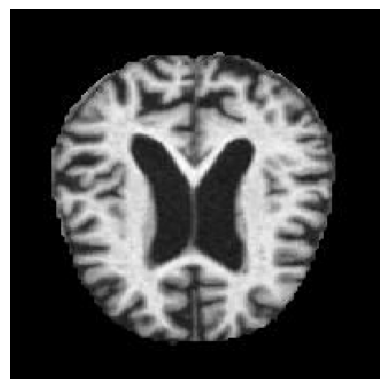

1/1 [==============================] - 0s 34ms/step
98.15 % chances are there that the image is ModerateDemented


In [34]:
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

# Dictionary for class indices
dic = test_dataset.class_indices
idc = {v: k for k, v in dic.items()}

# Load and preprocess the image
img = load_img('/content/Alzheimer_s Dataset/test/ModerateDemented/27 (2).jpg', target_size=(224, 224, 3))
img = img_to_array(img)
img = img / 255.0

# Display the image
plt.imshow(img)
plt.axis('off')
plt.show()

# Expand dimensions to match the input shape for the model
img = np.expand_dims(img, axis=0)

# Make a prediction
predictions = model.predict(img)
answer = np.argmax(predictions, axis=1)
probability = round(np.max(predictions) * 100, 2)

print(f"{probability} % chances are there that the image is {idc[answer[0]]}")


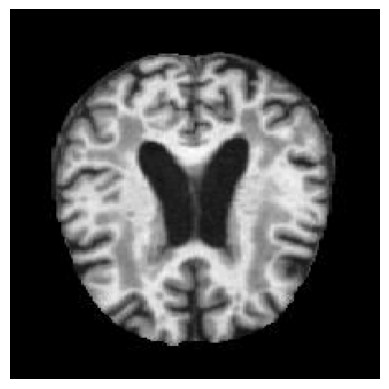

1/1 [==============================] - 0s 59ms/step
83.68 % chances are there that the image is VeryMildDemented


In [35]:
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

# Dictionary for class indices
dic = test_dataset.class_indices
idc = {v: k for k, v in dic.items()}

# Load and preprocess the image
img = load_img('/content/Alzheimer_s Dataset/test/VeryMildDemented/26 (55).jpg', target_size=(224, 224, 3))
img = img_to_array(img)
img = img / 255.0

# Display the image
plt.imshow(img)
plt.axis('off')
plt.show()

# Expand dimensions to match the input shape for the model
img = np.expand_dims(img, axis=0)

# Make a prediction
predictions = model.predict(img)
answer = np.argmax(predictions, axis=1)
probability = round(np.max(predictions) * 100, 2)

print(f"{probability} % chances are there that the image is {idc[answer[0]]}")


Conclusion:

So, we have finally built are deep learning model using DenseNet162 transfer learning algorithm and acheived and AUC-90%.